In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heights/Heights.csv


# Reading the data

In [4]:
df = pd.read_csv('/kaggle/input/heights/Heights.csv')

In [6]:
df.head()

,Weight,Shoesize,Height
0,89.0,10,180.00
1,59.0,7,167.64
2,74.0,10,153.00
3,59.0,7,165.00
4,59.0,100,1650.00


In [7]:
X = df.drop(columns=['Height'])
y = df['Height']

# Statistics of the dataset features

In [8]:
X.describe()

,Weight,Shoesize
count,37.000000,37.000000
mean,67.609730,10.837838
std,9.769223,15.137359
min,49.000000,5.000000
25%,59.000000,7.000000
50%,70.000000,9.000000
75%,74.000000,10.000000
max,89.000000,100.000000


In [9]:
y.describe()

count      37.000000
mean      199.146486
std       247.993864
min         5.110000
25%       160.000000
50%       167.000000
75%       175.000000
max      1650.000000
Name: Height, dtype: float64

# Filtering the data

In [39]:
# First quartile
Q1 = df.quantile(0.25)
# Third quartile
Q3 = df.quantile(0.75)

# Inter quartile range
IQR = Q3 - Q1

In [40]:
mask = ~((df < (df - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)

In [41]:
df_clean = df[mask]

In [46]:
X_clean = df_clean.drop(columns=['Height'])
y_clean = df_clean['Height']

In [47]:
X_clean

,Weight,Shoesize
0,89.00,10
1,59.00,7
2,74.00,10
3,59.00,7
5,70.00,6
6,73.00,10
7,62.00,7
8,67.00,7
9,61.00,8
10,70.00,9


In [49]:
y_clean

0     180.00
1     167.64
2     153.00
3     165.00
5     153.00
6     185.00
7     167.00
8     167.64
9     162.00
10    172.00
11    170.00
12    153.00
13    158.00
14    171.00
15    175.00
16    170.18
17    170.17
18    164.00
19    189.00
20    167.00
21    165.00
22    167.00
23    181.00
24    159.00
25    184.00
26    153.00
27    164.00
28    167.00
29    177.00
30    160.00
31    172.00
32      5.11
33    179.00
34    180.34
35     18.34
36    127.00
Name: Height, dtype: float64

# Bar plots

In [33]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'x-clean'}>

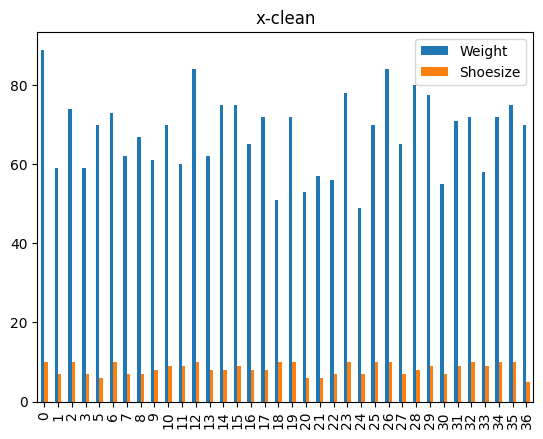

In [56]:
X_clean.plot(kind='bar',title='x-clean')

<Axes: title={'center': 'y-clean'}>

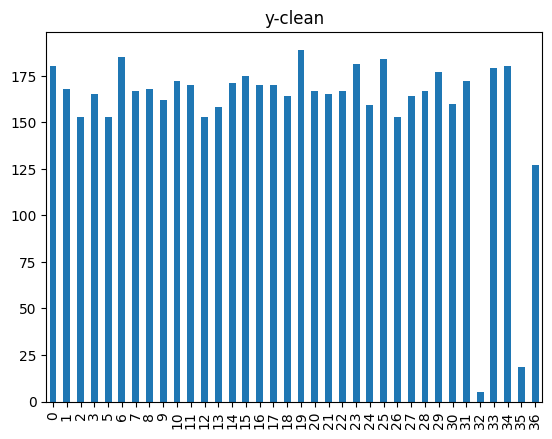

In [55]:
y_clean.plot(kind='bar', title='y-clean')

# Printing shoesize>10 instances

In [52]:
df[df['Shoesize']>=10]

,Weight,Shoesize,Height
0,89.0,10,180.00
2,74.0,10,153.00
4,59.0,100,1650.00
6,73.0,10,185.00
12,84.0,10,153.00
18,51.0,10,164.00
19,72.0,10,189.00
23,78.0,10,181.00
25,70.0,10,184.00
26,84.0,10,153.00


# Custom Dataframe

In [61]:
# CUSTOM DATAFRAME

people_dict = {
    "weight" : pd.Series([80,67,65],index=['charles','bob','harry']),
    "height" : pd.Series([167,180.33,164],index=['charles','bob','harry']),
    "father-name" : pd.Series(['David','Steve','Pat'],index=['charles','bob','harry'])
}

In [62]:
custom_df = pd.DataFrame(people_dict)
custom_df

,weight,height,father-name
charles,80,167.00,David
bob,67,180.33,Steve
harry,65,164.00,Pat
